<a href="https://colab.research.google.com/github/dennisddschulz/cas-artificial-intelligence/blob/main/06_transformer/04_Assignment_%E2%80%93_Encoder_Decoder_mit_Attention_(Seq2Seq)_%26_Br%C3%BCcke_zu_Transformern_Aufgabe_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 Assignment – Encoder-Decoder mit Attention (Seq2Seq) & Brücke zu Transformern

Bern University of Applied Sciences – CAS AI HS 25  
Dozent: Ilja Rasin  

Dieses Notebook gehört zur vierten Vorlesung (Transformer & Attention).

**Ziele der Einheit**

- Wiederholung: LSTM als Baustein für Sequenzmodelle  
- Encoder-Decoder-Architektur (Seq2Seq) verstehen  
- Dot-Product-Attention auf Basis von LSTM implementieren  
- Attention-Gewichte visualisieren (Heatmap)  
- Einen ersten Blick auf "große" Transformer-Modelle mit Hugging Face werfen

## 1. Imports & Setup

In [1]:

import math
import random
from typing import List, Tuple

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

## 2. Mini-Datensatz: einfache “Übersetzung”

In [2]:
pairs = [
    ("eins zwei drei", "one two three"),
    ("vier fünf", "four five"),
    ("eins zwei", "one two"),
    ("drei vier fünf", "three four five"),
    ("wir lieben pytorch", "we love pytorch"),
    ("ich lerne ki", "i learn ai"),
    ("hallo welt", "hello world"),
    ("guten morgen", "good morning"),
    ("wie geht es dir", "how are you"),
    ("ich bin gut", "i am good"),
    ("das ist toll", "that is great"),
    ("das ist ein sehr langes und komplexes beispiel", "this is a very long and complex example"),
    ("der himmel ist blau und die sonne scheint hell", "the sky is blue and the sun shines brightly"),
    ("bitte übersetze diesen satz für mich", "please translate this sentence for me"),
    ("wir müssen mehr über neuronale netze lernen", "we must learn more about neural networks"),
    ("ich möchte heute abend einen film schauen", "i want to watch a movie tonight"),
    ("die künstliche intelligenz verändert die welt", "artificial intelligence is changing the world"),
    ("mein computer ist schnell und zuverlässig", "my computer is fast and reliable"),
    ("dieses beispiel sollte länger sein als die anderen", "this example should be longer than the others"),
]

# Wir fügen zusätzlich ein paar Zufallsvarianten auf Basis der Zahlen ein
de_numbers = ["eins", "zwei", "drei", "vier", "fünf"]
en_numbers = ["one", "two", "three", "four", "five"]

for _ in range(50): # Erhöhte die Anzahl der Zufallsbeispiele von 25 auf 50
    length = random.randint(3, 6) # Erhöhen Sie die maximale Länge der Zufallszahlen
    idxs = [random.randint(0, 4) for _ in range(length)]
    src = " ".join(de_numbers[i] for i in idxs)
    trg = " ".join(en_numbers[i] for i in idxs)
    pairs.append((src, trg))

len(pairs), pairs[:20]

(69,
 [('eins zwei drei', 'one two three'),
  ('vier fünf', 'four five'),
  ('eins zwei', 'one two'),
  ('drei vier fünf', 'three four five'),
  ('wir lieben pytorch', 'we love pytorch'),
  ('ich lerne ki', 'i learn ai'),
  ('hallo welt', 'hello world'),
  ('guten morgen', 'good morning'),
  ('wie geht es dir', 'how are you'),
  ('ich bin gut', 'i am good'),
  ('das ist toll', 'that is great'),
  ('das ist ein sehr langes und komplexes beispiel',
   'this is a very long and complex example'),
  ('der himmel ist blau und die sonne scheint hell',
   'the sky is blue and the sun shines brightly'),
  ('bitte übersetze diesen satz für mich',
   'please translate this sentence for me'),
  ('wir müssen mehr über neuronale netze lernen',
   'we must learn more about neural networks'),
  ('ich möchte heute abend einen film schauen',
   'i want to watch a movie tonight'),
  ('die künstliche intelligenz verändert die welt',
   'artificial intelligence is changing the world'),
  ('mein computer is

## 3. Vokabular & Tokenisierung

### Ausführliche Erklärung

itos steht für index-to-string.
Das heißt: Wenn wir einen Index haben, können wir damit das entsprechende Wort (Token) nachschlagen.

Beim Aufbau des Vokabulars (build_vocab) erzeugen wir eine Liste aller Tokens, die die Reihenfolge festlegt.

Diese Liste sieht z. B. so aus:
```
itos = [
    "<pad>",    # Index 0
    "<sos>",    # Index 1
    "<eos>",    # Index 2
    "drei",     # Index 3
    "eins",     # Index 4
    "fünf",     # Index 5
    "vier",     # Index 6
    "zwei"      # Index 7
]
```

Damit wird klar:

```itos[0] == "<pad>"```
Das Token <pad> (“Padding”) hat den Index 0.
Es wird verwendet, um Sequenzen auf gleiche Länge zu bringen.

```itos[1] == "<sos>"```
<sos> (“start of sequence”) hat den Index 1.
Der Decoder beginnt die Generierung immer mit diesem Token.

```itos[2] == "<eos>"```
<eos> (“end of sequence”) hat den Index 2.
Sobald der Decoder dieses Token ausgibt, ist der Satz beendet.

```itos[3] == "drei"```
Das tatsächliche Wort „drei“ bekommt den Index 3.
Es ist das erste „echte“ Wort im Vokabular nach den drei Spezial-Tokens.

**Warum genau in dieser Reihenfolge?**

Die drei Sondertokens haben immer feste Plätze (0, 1, 2).
Das macht Training und Paddings logischer und reproduzierbar.

Alle anderen Wörter (z. B. „drei“, „eins“, „zwei“ …) werden alphabetisch sortiert eingefügt.
Das hat keinen Einfluss auf das Lernen, sorgt aber dafür, dass das Vokabular jedes Mal im selben Aufbau entsteht.

In [3]:
# Spezielle Tokens

# "<pad>" — padding token
# "<sos>" — start-of-sequence
# "<eos>" — end-of-sequence
PAD_TOKEN = "<pad>"
SOS_TOKEN = "<sos>"
EOS_TOKEN = "<eos>"

def build_vocab(sentences: List[str]):
    tokens = set()
    for s in sentences:
        tokens.update(s.split())

    # itos — index-to-string
    itos = [PAD_TOKEN, SOS_TOKEN, EOS_TOKEN] + sorted(tokens)
    print("itos: ", itos)

    # itos[0] == "<pad>"
    # itos[1] == "<sos>"
    # itos[2] == "<eos>"
    # itos[3] == "drei"

    stoi = {tok: i for i, tok in enumerate(itos)}
    print("stoi: ", stoi)
    return stoi, itos

src_sentences = [p[0] for p in pairs]
trg_sentences = [p[1] for p in pairs]

src_stoi, src_itos = build_vocab(src_sentences)
trg_stoi, trg_itos = build_vocab(trg_sentences)

SRC_VOCAB_SIZE = len(src_itos)
TRG_VOCAB_SIZE = len(trg_itos)

SRC_VOCAB_SIZE, TRG_VOCAB_SIZE, src_itos, trg_itos


itos:  ['<pad>', '<sos>', '<eos>', 'abend', 'als', 'anderen', 'beispiel', 'bin', 'bitte', 'blau', 'computer', 'das', 'der', 'die', 'diesen', 'dieses', 'dir', 'drei', 'ein', 'einen', 'eins', 'es', 'film', 'fünf', 'für', 'geht', 'gut', 'guten', 'hallo', 'hell', 'heute', 'himmel', 'ich', 'intelligenz', 'ist', 'ki', 'komplexes', 'künstliche', 'langes', 'lerne', 'lernen', 'lieben', 'länger', 'mehr', 'mein', 'mich', 'morgen', 'möchte', 'müssen', 'netze', 'neuronale', 'pytorch', 'satz', 'schauen', 'scheint', 'schnell', 'sehr', 'sein', 'sollte', 'sonne', 'toll', 'und', 'verändert', 'vier', 'welt', 'wie', 'wir', 'zuverlässig', 'zwei', 'über', 'übersetze']
stoi:  {'<pad>': 0, '<sos>': 1, '<eos>': 2, 'abend': 3, 'als': 4, 'anderen': 5, 'beispiel': 6, 'bin': 7, 'bitte': 8, 'blau': 9, 'computer': 10, 'das': 11, 'der': 12, 'die': 13, 'diesen': 14, 'dieses': 15, 'dir': 16, 'drei': 17, 'ein': 18, 'einen': 19, 'eins': 20, 'es': 21, 'film': 22, 'fünf': 23, 'für': 24, 'geht': 25, 'gut': 26, 'guten': 27, 

(71,
 65,
 ['<pad>',
  '<sos>',
  '<eos>',
  'abend',
  'als',
  'anderen',
  'beispiel',
  'bin',
  'bitte',
  'blau',
  'computer',
  'das',
  'der',
  'die',
  'diesen',
  'dieses',
  'dir',
  'drei',
  'ein',
  'einen',
  'eins',
  'es',
  'film',
  'fünf',
  'für',
  'geht',
  'gut',
  'guten',
  'hallo',
  'hell',
  'heute',
  'himmel',
  'ich',
  'intelligenz',
  'ist',
  'ki',
  'komplexes',
  'künstliche',
  'langes',
  'lerne',
  'lernen',
  'lieben',
  'länger',
  'mehr',
  'mein',
  'mich',
  'morgen',
  'möchte',
  'müssen',
  'netze',
  'neuronale',
  'pytorch',
  'satz',
  'schauen',
  'scheint',
  'schnell',
  'sehr',
  'sein',
  'sollte',
  'sonne',
  'toll',
  'und',
  'verändert',
  'vier',
  'welt',
  'wie',
  'wir',
  'zuverlässig',
  'zwei',
  'über',
  'übersetze'],
 ['<pad>',
  '<sos>',
  '<eos>',
  'a',
  'about',
  'ai',
  'am',
  'and',
  'are',
  'artificial',
  'be',
  'blue',
  'brightly',
  'changing',
  'complex',
  'computer',
  'example',
  'fast',
  '

In [4]:
def encode_sentence(sentence: str, stoi: dict, add_sos_eos: bool = True):
    tokens = sentence.split()
    ids = [stoi[t] for t in tokens]
    if add_sos_eos:
        ids = [stoi[SOS_TOKEN]] + ids + [stoi[EOS_TOKEN]]
    return ids

max_len_src = max(len(encode_sentence(s, src_stoi)) for s in src_sentences)
max_len_trg = max(len(encode_sentence(s, trg_stoi)) for s in trg_sentences)
max_len_src, max_len_trg


(11, 11)

In [5]:
for s in src_sentences:
  encoded_ids = encode_sentence(s, src_stoi)
  print(s, encoded_ids)

eins zwei drei [1, 20, 68, 17, 2]
vier fünf [1, 63, 23, 2]
eins zwei [1, 20, 68, 2]
drei vier fünf [1, 17, 63, 23, 2]
wir lieben pytorch [1, 66, 41, 51, 2]
ich lerne ki [1, 32, 39, 35, 2]
hallo welt [1, 28, 64, 2]
guten morgen [1, 27, 46, 2]
wie geht es dir [1, 65, 25, 21, 16, 2]
ich bin gut [1, 32, 7, 26, 2]
das ist toll [1, 11, 34, 60, 2]
das ist ein sehr langes und komplexes beispiel [1, 11, 34, 18, 56, 38, 61, 36, 6, 2]
der himmel ist blau und die sonne scheint hell [1, 12, 31, 34, 9, 61, 13, 59, 54, 29, 2]
bitte übersetze diesen satz für mich [1, 8, 70, 14, 52, 24, 45, 2]
wir müssen mehr über neuronale netze lernen [1, 66, 48, 43, 69, 50, 49, 40, 2]
ich möchte heute abend einen film schauen [1, 32, 47, 30, 3, 19, 22, 53, 2]
die künstliche intelligenz verändert die welt [1, 13, 37, 33, 62, 13, 64, 2]
mein computer ist schnell und zuverlässig [1, 44, 10, 34, 55, 61, 67, 2]
dieses beispiel sollte länger sein als die anderen [1, 15, 6, 58, 42, 57, 4, 13, 5, 2]
eins drei zwei [1, 20, 1

In [6]:
def pad_sequence(seq: List[int], max_len: int, pad_idx: int) -> List[int]:
    return seq + [pad_idx] * (max_len - len(seq))

PAD_IDX_TRG = trg_stoi[PAD_TOKEN]
PAD_IDX_SRC = src_stoi[PAD_TOKEN]

dataset = []
for src, trg in pairs:
    src_ids = encode_sentence(src, src_stoi)
    trg_ids = encode_sentence(trg, trg_stoi)
    src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
    trg_ids = pad_sequence(trg_ids, max_len_trg, PAD_IDX_TRG)
    dataset.append((src_ids, trg_ids))

len(dataset), dataset[0]


(69,
 ([1, 20, 68, 17, 2, 0, 0, 0, 0, 0, 0], [1, 40, 58, 54, 2, 0, 0, 0, 0, 0, 0]))

In [7]:
# Mini-Dataloader

def batchify(dataset, batch_size: int):
    random.shuffle(dataset)
    for i in range(0, len(dataset), batch_size):
        batch = dataset[i:i+batch_size]
        src_batch = torch.tensor([b[0] for b in batch], dtype=torch.long, device=device)
        trg_batch = torch.tensor([b[1] for b in batch], dtype=torch.long, device=device)
        yield src_batch, trg_batch


## 4. Encoder-Decoder ohne Attention

### Encoder

In [8]:
class Encoder(nn.Module):
    def __init__(self, input_dim, emb_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, emb_dim, padding_idx=PAD_IDX_SRC)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True)

    def forward(self, src):
        # src: [B, src_len]
        embedded = self.embedding(src)           # [B, src_len, emb_dim]
        outputs, (hidden, cell) = self.lstm(embedded)  # outputs: [B, src_len, H]
        return outputs, (hidden, cell)


### Decoder ohne Attention

In [9]:
class Decoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim, num_layers=1):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX_TRG)
        self.lstm = nn.LSTM(emb_dim, hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input, hidden, cell):
        # input: [B] (aktuelles Token-Index)
        input = input.unsqueeze(1)  # [B, 1]
        embedded = self.embedding(input)  # [B, 1, emb_dim]
        output, (hidden, cell) = self.lstm(embedded, (hidden, cell))
        # output: [B, 1, H]
        prediction = self.fc_out(output.squeeze(1))  # [B, output_dim]
        return prediction, hidden, cell


## 5. Seq2Seq Wrapper

## Wie funktioniert ein Seq2Seq-Modell?
**Encoder**

- erhält die gesamte Eingabesequenz (**[eins, zwei, drei])**
- verarbeitet sie tokenweise (LSTM-Zeitdimension)
- erzeugt einen „Kontextvektor“ (hidden, cell)
- dieser Kontext repräsentiert die **Bedeutung** des ganzen Satzes

**Decoder**

- bekommt nicht die Eingabewörter
- bekommt nur den Kontext + \<sos> als Startsignal
- generiert das Zielsatz Wort für Wort

**Beispiel**:

- Source: "eins zwei drei"
- Target: "one two three"


Decoder erzeugt:

\<sos> → one
one → two
two → three
three → \<eos>


Er versucht nicht, "eins" zu rekonstruieren.
Er versucht, die Zielsequenz zu generieren.

### Seq2Seq-Klasse – ausführliche Erklärung

Der folgende Code implementiert den kompletten Ablauf eines Encoder-Decoder-Modells (Seq2Seq):
```
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg
```

Was passiert hier?

**encoder**: verarbeitet den Eingabesatz

**decoder**: generiert den Ausgabesatz

**trg_sos_idx**: Index des <sos>-Tokens

**trg_eos_idx**: Index des <eos>-Tokens

**max_len_trg**: maximale Länge der Zielsequenz

```
def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
    batch_size = src.size(0)
    trg_len = self.max_len_trg
    trg_vocab_size = self.decoder.fc_out.out_features
```

**Bedeutung**:

**batch_size**: Anzahl der Sätze im Batch

**trg_len**: wie viele Schritte der Decoder generieren soll

**trg_vocab_size**: Größe des Zielvokabulars (für Softmax)

outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)


**Wir erzeugen eine große Ausgabe-Matrix, in der der Decoder seine Vorhersagen ablegt:**
```
Form:
[Batch, Zeit, Vokabulargröße]

encoder_outputs, (hidden, cell) = self.encoder(src)
```


**Der Encoder liefert:**

encoder_outputs: alle LSTM-Outputs (für Attention)

hidden, cell: letzter versteckter Zustand — initialer Zustand des Decoders
```
input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)
```


**Der Decoder startet immer mit dem <sos>-Token.**

Hauptschleife
```
for t in range(trg_len):
    output, hidden, cell = self.decoder(input, hidden, cell)
    outputs[:, t, :] = output
```


Der Decoder arbeitet Schritt für Schritt:

1. erhält das aktuelle Token

2. aktualisiert seinen Zustand

3. produziert eine Wahrscheinlichkeitsverteilung über das Vokabular. Diese speichern wir in outputs

**Teacher Forcing**
```
if trg is not None and random.random() < teacher_forcing_ratio:
    input = trg[:, t]  # das echte Token
else:
    input = output.argmax(dim=1)  # das vorhergesagte Token
```

**Teacher Forcing: schnelleres Lernen**

Ohne Teacher Forcing: Modell lernt, selbstständig zu generieren

Rückgabe
```
return outputs
```

Ein Tensor der Form:
```
[Batch, Sequenzlänge, Vokabulargröße]
```

### Teacher Forcing – Erklärung auf Deutsch für Studierende

Teacher Forcing ist eine Trainingsstrategie im Decoder eines Seq2Seq-Modells.

Bei jedem Zeitschritt entscheidet das Modell:

Soll ich das nächste Wort anhand des korrekten Trainingstokens erzeugen
oder anhand meines eigenen vorherigen Outputs?

- Mit Teacher Forcing

Der Decoder erhält das richtige Wort aus der Zielsequenz.
Dadurch lernt er schneller und sammelt keine Fehler auf.

- Ohne Teacher Forcing

Der Decoder erhält sein eigenes vorhergesagtes Wort.
Das ist wichtig, um später autonom Sätze zu generieren.

> **Problem ohne Teacher Forcing**

Wenn der Decoder früh einen Fehler macht, baut sich dieser Fehler auf —
die gesamte Ausgabe kann kollabieren.

> **Lösung**

Wir mischen beides, z. B. teacher_forcing_ratio = 0.5:

if random.random() < teacher_forcing_ratio:
    input = target_token     # richtiges Token
else:
    input = predicted_token  # Modellvorhersage


So lernt der Decoder korrekt zu folgen aber auch selbstständig zu generieren

Das ergibt robustes Seq2Seq-Verhalten.

In [10]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = self.max_len_trg
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)

        for t in range(trg_len):
            output, hidden, cell = self.decoder(input, hidden, cell)
            outputs[:, t, :] = output

            if trg is not None and random.random() < teacher_forcing_ratio:
                input = trg[:, t]
            else:
                input = output.argmax(dim=1)

        return outputs


## Model + Loss

In [11]:
EMB_DIM = 64
HID_DIM = 128

encoder = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
decoder = Decoder(TRG_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)

model = Seq2Seq(
    encoder,
    decoder,
    trg_sos_idx=trg_stoi[SOS_TOKEN],
    trg_eos_idx=trg_stoi[EOS_TOKEN],
    max_len_trg=max_len_trg
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX_TRG)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

## Training (erstmal ohne Attention)

In [12]:
def train_epoch(model, dataset, batch_size=8, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0
    for src_batch, trg_batch in batchify(dataset, batch_size):
        optimizer.zero_grad()
        outputs = model(src_batch, trg_batch, teacher_forcing_ratio)
        # outputs: [B, T, V]
        B, T, V = outputs.shape
        loss = criterion(
            outputs.view(B*T, V),
            trg_batch.view(B*T)
        )
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / (len(dataset) / batch_size)

for epoch in range(100): # Erhöhte Epochenzahl
    loss = train_epoch(model, dataset, batch_size=8, teacher_forcing_ratio=0.7)
    print(f"Epoch {epoch+1}: loss={loss:.3f}")

Epoch 1: loss=4.217
Epoch 2: loss=3.499
Epoch 3: loss=2.655
Epoch 4: loss=2.341
Epoch 5: loss=2.270
Epoch 6: loss=2.205
Epoch 7: loss=2.109
Epoch 8: loss=2.049
Epoch 9: loss=2.029
Epoch 10: loss=1.920
Epoch 11: loss=1.857
Epoch 12: loss=1.794
Epoch 13: loss=1.704
Epoch 14: loss=1.621
Epoch 15: loss=1.600
Epoch 16: loss=1.528
Epoch 17: loss=1.508
Epoch 18: loss=1.449
Epoch 19: loss=1.384
Epoch 20: loss=1.368
Epoch 21: loss=1.342
Epoch 22: loss=1.272
Epoch 23: loss=1.237
Epoch 24: loss=1.234
Epoch 25: loss=1.176
Epoch 26: loss=1.165
Epoch 27: loss=1.071
Epoch 28: loss=1.094
Epoch 29: loss=1.026
Epoch 30: loss=0.998
Epoch 31: loss=0.951
Epoch 32: loss=0.937
Epoch 33: loss=0.890
Epoch 34: loss=0.867
Epoch 35: loss=0.807
Epoch 36: loss=0.786
Epoch 37: loss=0.740
Epoch 38: loss=0.696
Epoch 39: loss=0.664
Epoch 40: loss=0.665
Epoch 41: loss=0.632
Epoch 42: loss=0.641
Epoch 43: loss=0.575
Epoch 44: loss=0.572
Epoch 45: loss=0.583
Epoch 46: loss=0.540
Epoch 47: loss=0.484
Epoch 48: loss=0.462
E

## Eine Funktion zur Generierung

In [13]:
def indices_to_sentence(indices: List[int], itos: List[str]):
    tokens = []
    for idx in indices:
        tok = itos[idx]
        if tok == EOS_TOKEN:
            break
        if tok not in (SOS_TOKEN, PAD_TOKEN):
            tokens.append(tok)
    return " ".join(tokens)

def translate_example(model, src_sentence: str):
    model.eval()
    with torch.no_grad():
        src_ids = encode_sentence(src_sentence, src_stoi)
        src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
        src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

        outputs = model(src_tensor, trg=None, teacher_forcing_ratio=0.0)
        # outputs: [1, T, V]
        preds = outputs.argmax(dim=-1).squeeze(0).tolist()
        return indices_to_sentence(preds, trg_itos)

for s, t in random.sample(pairs, 20):
    pred = translate_example(model, s)
    print(f"DE: {s}")
    print(f"GT: {t}")
    print(f"PR: {pred}\n")


DE: drei vier drei vier
GT: three four three four
PR: three four three four

DE: bitte übersetze diesen satz für mich
GT: please translate this sentence for me
PR: please translate this sentence for me

DE: vier drei eins
GT: four three one
PR: four three one

DE: das ist toll
GT: that is great
PR: that is great

DE: vier drei vier
GT: four three four
PR: four three four

DE: vier fünf
GT: four five
PR: four five

DE: vier fünf vier zwei zwei
GT: four five four two two
PR: four five four two two

DE: zwei eins eins
GT: two one one
PR: two one one

DE: zwei vier vier zwei eins eins
GT: two four four two one one
PR: two four four two one one

DE: drei vier vier vier eins eins
GT: three four four four one one
PR: three four four four one one

DE: vier eins zwei vier
GT: four one two four
PR: four one two four

DE: eins drei fünf zwei fünf eins
GT: one three five two five one
PR: one three five two five one

DE: hallo welt
GT: hello world
PR: hello world

DE: ich lerne ki
GT: i learn ai
PR

## 6. Dot-Product Attention hinzufügen (ATTENTION:  Attention$→$ NÄCHSTE SITZUNG!)

In [14]:
class DotProductAttention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, decoder_hidden, encoder_outputs, mask=None):
        # decoder_hidden: [B, H] (aktueller hidden state der Decoder-LSTM)
        # encoder_outputs: [B, src_len, H]
        # scores: [B, src_len]
        scores = torch.bmm(encoder_outputs, decoder_hidden.unsqueeze(2)).squeeze(2)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)

        attn_weights = torch.softmax(scores, dim=1)  # [B, src_len]

        # Kontext: gewichtete Summe der Encoder-Outputs
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [B, H]
        return context, attn_weights


### Decoder mit Attention

In [15]:
class AttnDecoder(nn.Module):
    def __init__(self, output_dim, emb_dim, hidden_dim):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, emb_dim, padding_idx=PAD_IDX_TRG)
        self.lstm = nn.LSTM(emb_dim + hidden_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
        self.attention = DotProductAttention()

    def forward(self, input, hidden, cell, encoder_outputs):
        # input: [B]
        input = input.unsqueeze(1)  # [B, 1]
        embedded = self.embedding(input)  # [B, 1, emb_dim]

        dec_hidden = hidden[-1]  # [B, H] - letzte Layer
        context, attn_weights = self.attention(dec_hidden, encoder_outputs)  # [B, H], [B, src_len]

        context = context.unsqueeze(1)  # [B, 1, H]
        lstm_input = torch.cat([embedded, context], dim=2)  # [B, 1, emb_dim + H]

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))  # [B, output_dim]
        return prediction, hidden, cell, attn_weights


### Seq2Seq mit Attention (leicht modifiziert)

In [16]:
class AttnSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_idx, trg_eos_idx, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_idx = trg_sos_idx
        self.trg_eos_idx = trg_eos_idx
        self.max_len_trg = max_len_trg

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = self.max_len_trg
        trg_vocab_size = self.decoder.fc_out.out_features

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size, device=device)
        all_attn = torch.zeros(batch_size, trg_len, src.size(1), device=device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        input = torch.full((batch_size,), self.trg_sos_idx, dtype=torch.long, device=device)

        for t in range(trg_len):
            output, hidden, cell, attn_weights = self.decoder(input, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output
            all_attn[:, t, :] = attn_weights

            if trg is not None and random.random() < teacher_forcing_ratio:
                input = trg[:, t]
            else:
                input = output.argmax(dim=1)

        return outputs, all_attn


### Model + Training

In [17]:
encoder_attn = Encoder(SRC_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)
decoder_attn =  AttnDecoder(TRG_VOCAB_SIZE, EMB_DIM, HID_DIM).to(device)

model_attn = AttnSeq2Seq(
    encoder_attn,
    decoder_attn,
    trg_sos_idx=trg_stoi[SOS_TOKEN],
    trg_eos_idx=trg_stoi[EOS_TOKEN],
    max_len_trg=max_len_trg
).to(device)

optimizer_attn = optim.Adam(model_attn.parameters(), lr=1e-3)
criterion_attn = nn.CrossEntropyLoss(ignore_index=PAD_IDX_TRG)

def train_epoch_attn(model, dataset, batch_size=8, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0
    for src_batch, trg_batch in batchify(dataset, batch_size):
        optimizer_attn.zero_grad()
        outputs, _ = model(src_batch, trg_batch, teacher_forcing_ratio)
        B, T, V = outputs.shape
        loss = criterion_attn(
            outputs.view(B*T, V),
            trg_batch.view(B*T)
        )
        loss.backward()
        optimizer_attn.step()
        total_loss += loss.item()
    return total_loss / (len(dataset) / batch_size)

for epoch in range(50): # Erhöhte Epochenzahl
    loss = train_epoch_attn(model_attn, dataset, batch_size=8, teacher_forcing_ratio=0.7)
    print(f"[ATTN] Epoch {epoch+1}: loss={loss:.3f}")

[ATTN] Epoch 1: loss=4.149
[ATTN] Epoch 2: loss=3.184
[ATTN] Epoch 3: loss=2.527
[ATTN] Epoch 4: loss=2.361
[ATTN] Epoch 5: loss=2.166
[ATTN] Epoch 6: loss=2.052
[ATTN] Epoch 7: loss=1.903
[ATTN] Epoch 8: loss=1.825
[ATTN] Epoch 9: loss=1.751
[ATTN] Epoch 10: loss=1.683
[ATTN] Epoch 11: loss=1.628
[ATTN] Epoch 12: loss=1.564
[ATTN] Epoch 13: loss=1.536
[ATTN] Epoch 14: loss=1.462
[ATTN] Epoch 15: loss=1.402
[ATTN] Epoch 16: loss=1.328
[ATTN] Epoch 17: loss=1.331
[ATTN] Epoch 18: loss=1.235
[ATTN] Epoch 19: loss=1.224
[ATTN] Epoch 20: loss=1.179
[ATTN] Epoch 21: loss=1.132
[ATTN] Epoch 22: loss=1.084
[ATTN] Epoch 23: loss=1.063
[ATTN] Epoch 24: loss=0.998
[ATTN] Epoch 25: loss=0.966
[ATTN] Epoch 26: loss=0.981
[ATTN] Epoch 27: loss=0.929
[ATTN] Epoch 28: loss=0.864
[ATTN] Epoch 29: loss=0.831
[ATTN] Epoch 30: loss=0.778
[ATTN] Epoch 31: loss=0.736
[ATTN] Epoch 32: loss=0.718
[ATTN] Epoch 33: loss=0.687
[ATTN] Epoch 34: loss=0.631
[ATTN] Epoch 35: loss=0.606
[ATTN] Epoch 36: loss=0.582
[

### Eine Funktion zur Übersetzung und Visualisierung der Attention

Quellsatz: fünf drei fünf zwei eins
Vorhersage: five three five two one


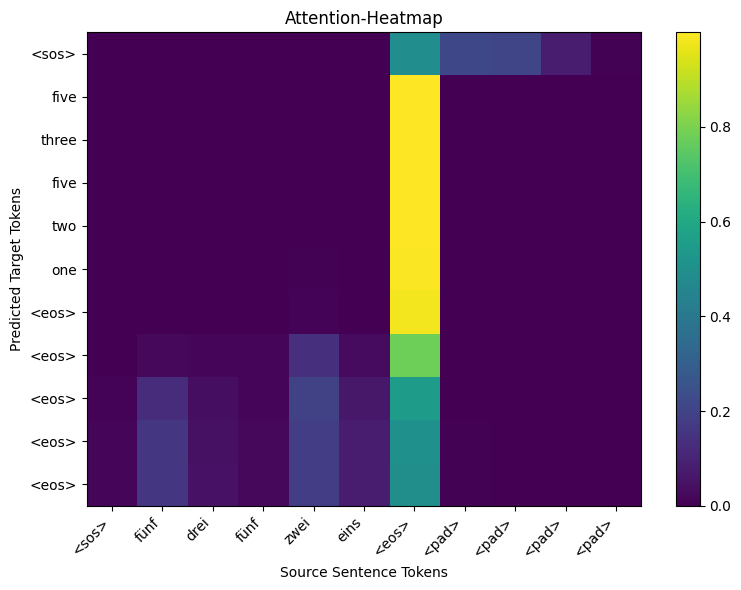

In [18]:
def translate_with_attention(model, src_sentence: str):
    model.eval()
    with torch.no_grad():
        src_ids = encode_sentence(src_sentence, src_stoi)
        src_ids = pad_sequence(src_ids, max_len_src, PAD_IDX_SRC)
        src_tensor = torch.tensor([src_ids], dtype=torch.long, device=device)

        outputs, attn = model(src_tensor, trg=None, teacher_forcing_ratio=0.0)
        preds = outputs.argmax(dim=-1).squeeze(0).tolist()
        attn = attn.squeeze(0).cpu().numpy()  # [trg_len, src_len]

        pred_sentence = indices_to_sentence(preds, trg_itos)
        return pred_sentence, attn, src_ids, preds

example_src = random.choice(pairs)[0]
pred_sentence, attn_matrix, src_ids, raw_preds = translate_with_attention(model_attn, example_src)

print("Quellsatz:", example_src)
print("Vorhersage:", pred_sentence)

src_tokens = [src_itos[i] for i in src_ids]

# Neue trg_tokens, um alle vorhergesagten Schritte anzuzeigen, auch Padding
trg_tokens_for_plot = [trg_itos[i] for i in raw_preds]

plt.figure(figsize=(8, 6))
plt.imshow(attn_matrix[:len(trg_tokens_for_plot), :len(src_tokens)], aspect='auto')
plt.xticks(range(len(src_tokens)), src_tokens, rotation=45, ha='right')
plt.yticks(range(len(trg_tokens_for_plot)), trg_tokens_for_plot)
plt.colorbar()
plt.title("Attention-Heatmap")
plt.xlabel("Source Sentence Tokens")
plt.ylabel("Predicted Target Tokens")
plt.tight_layout()
plt.show()


## 7. Mini-HuggingFace Demo: “Großer” Transformer

In [19]:
!pip install -q transformers sentencepiece

In [20]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_name = "Helsinki-NLP/opus-mt-de-en"  # kleiner Übersetzungs-Transformer
tokenizer_hf = AutoTokenizer.from_pretrained(model_name)
model_hf = AutoModelForSeq2SeqLM.from_pretrained(model_name).to(device)

def translate_hf(text: str):
    inputs = tokenizer_hf(text, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model_hf.generate(**inputs, max_new_tokens=50)
    return tokenizer_hf.batch_decode(outputs, skip_special_tokens=True)[0]

example_text = "Wir lernen heute Attention und Transformer."
print(translate_hf(example_text))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

source.spm:   0%|          | 0.00/797k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/768k [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/298M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/298M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

We're learning attention and transformer today.


### Aufgabe (HuggingFace)

1. Ändern Sie `example_text` und testen Sie eigene Sätze.  
2. Probieren Sie (optional) ein anderes Modell aus, z.B.:
   - Summarization (`google/pegasus-xsum`)
   - Deutsch-Deutsch-Paraphrasierung o.ä.  

> Ziel: Gefühl dafür bekommen, wie Tokenizer + Transformer-Modell in der Praxis zusammenspielen.


## 8. Übungsaufgaben (Summary)

## Übungsaufgaben

1. **Eigene Sätze einbauen (Seq2Seq LSTM OHNE Attention)**  
   - Erweitern Sie die Liste `pairs` um eigene kleine Satzpaare (DE->EN oder sonstige Mapping-Aufgabe).  
   - Beobachten Sie, ob das Modell diese neuen Beispiele lernen kann.

2. **Hyperparameter-Experimente**  
   - Ändern Sie `EMB_DIM` und `HID_DIM`.  
   - Wie verändert sich die Trainingszeit und die Qualität der Vorhersagen?

3. **Hugging Face Exploration**  
   - Ändern Sie den Text in der HF-Demo und erläutern Sie in 2–3 Sätzen, was der Unterschied zwischen  
     unserem LSTM-Seq2Seq und dem vortrainierten Transformer-Modell ist (Datenmenge, Architektur, Qualität).
4. **Optionaler Task: Seq2Seq Forecasting (ohne Attention)**

Wir verwenden die bereits bekannte Encoder–Decoder Struktur aus der heutigen Vorlesung, aber diesmal nicht für Sprache, sondern für Zeitreihen.

**Ziel:**
Geben Sie die vergangenen n Werte in den Encoder und lassen Sie den Decoder die nächsten n Werte generieren.

**Hinweise:**

1. Entfernen Sie das Embedding — Zeitreihen sind numerisch.

2. src (Encoder Input) und trg (Decoder Target) sollen gleich lang sein.

3. \<sos> kann z.B. 0.0 sein oder ein learnable Parameter.

Der Decoder arbeitet autoregressiv:

\<sos> → y₁

y₁ → y₂

y₂ → y₃
… usw.

**Beispiel:**

Encoder Input:
x[t-9], x[t-8], …, x[t]

Decoder Output:
x[t+1], x[t+2], …, x[t+10]

# **Aufgabe:**
> Trainieren Sie das Modell auf Ihrem Datensatz und vergleichen Sie Seq2Seq LSTM Forecasting mit dem reinen LSTM aus der letzten Übung.


# Task
Download historical S&P 500 data (e.g., '^GSPC' or 'SPY'), preprocess it by extracting and normalizing 'Close' prices, and split it into training and testing sets. Create time series datasets for both an Encoder-Decoder LSTM and a standalone LSTM, where each sample consists of `n_past` values as input and `n_future` values as target. Adapt the existing `Encoder`, `AttnDecoder`, and `AttnSeq2Seq` classes by removing `nn.Embedding` layers and adjusting input/output dimensions and the `SOS_TOKEN` for numerical time series data. Implement a `LSTMForecaster` class with `input_size=1` and `output_size=n_future`. Initialize both the adapted `AttnSeq2Seq` and `LSTMForecaster` models, train them using `nn.MSELoss`, and evaluate their forecasting performance on the test set. Finally, visualize the actual S&P 500 values against the predictions from both models on the test data and provide a summary comparing their accuracy and discussing potential reasons for performance differences.

## Download and Preprocess S&P 500 Data

### Subtask:
Download historical S&P 500 data ('^GSPC' or 'SPY') using the `yfinance` library. Extract the 'Close' prices, normalize them (e.g., using MinMaxScaler), and split the data into training and testing sets. Define `n_past` (encoder input length) and `n_future` (decoder output/target length) for sequence creation.


**Reasoning**:
The first instruction is to install the `yfinance` library, which is done using `pip`.



In [21]:
import sys
!{sys.executable} -m pip install -q yfinance

**Reasoning**:
The next step is to import the `yfinance` and `MinMaxScaler` libraries and then download the historical S&P 500 data. It also includes extracting, reshaping, and normalizing the 'Close' prices using `MinMaxScaler`, as well as defining `n_past` and `n_future`.



In [22]:
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Download historical S&P 500 data
ticker = '^GSPC'  # S&P 500 index
data = yf.download(ticker, start='2010-01-01', end='2023-01-01')

# Extract 'Close' prices
close_prices = data['Close'].values

# Reshape for MinMaxScaler
close_prices = close_prices.reshape(-1, 1)

# Normalize the prices
scaler = MinMaxScaler(feature_range=(0, 1))
normalized_prices = scaler.fit_transform(close_prices)

# Define n_past and n_future
n_past = 10
n_future = 5

print(f"Original Close prices shape: {data['Close'].shape}")
print(f"Reshaped Close prices shape: {close_prices.shape}")
print(f"Normalized prices shape: {normalized_prices.shape}")
print(f"n_past: {n_past}, n_future: {n_future}")

/tmp/ipython-input-1181498038.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2010-01-01', end='2023-01-01')
[*********************100%***********************]  1 of 1 completed

Original Close prices shape: (3272, 1)
Reshaped Close prices shape: (3272, 1)
Normalized prices shape: (3272, 1)
n_past: 10, n_future: 5


**Reasoning**:
The previous code successfully downloaded, extracted, reshaped, and normalized the S&P 500 'Close' prices, and defined `n_past` and `n_future`. The next step is to create the time series datasets by splitting the normalized data into training and testing sets, ensuring the sequential nature of the data is preserved.



In [23]:
def create_sequences(data, n_past, n_future):
    X, y = [], []
    for i in range(len(data) - n_past - n_future + 1):
        X.append(data[i : i + n_past])
        y.append(data[i + n_past : i + n_past + n_future])
    return np.array(X), np.array(y)

# Create sequences for the entire dataset
X_full, y_full = create_sequences(normalized_prices, n_past, n_future)

# Split into training and testing sets (e.g., 80% train, 20% test)
train_size = int(len(X_full) * 0.8)

X_train, y_train = X_full[:train_size], y_full[:train_size]
X_test, y_test = X_full[train_size:], y_full[train_size:]

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_test: {y_test.shape}")


Shape of X_train: (2606, 10, 1)
Shape of y_train: (2606, 5, 1)
Shape of X_test: (652, 10, 1)
Shape of y_test: (652, 5, 1)


## Adapt Encoder for Time Series

### Subtask:
Modify the `Encoder` class to handle time series data by removing the `nn.Embedding` layer and adjusting the input dimension of the `nn.LSTM` to `input_size=1`.


**Reasoning**:
The next step is to define the `TimeSeriesEncoder` class by removing the `nn.Embedding` layer and setting the `input_size` of the `nn.LSTM` to 1, as specified in the instructions.



In [24]:
class TimeSeriesEncoder(nn.Module):
    def __init__(self, hidden_dim, num_layers=1):
        super().__init__()
        # Removed nn.Embedding layer
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)

    def forward(self, src):
        # src: [B, src_len, 1]
        outputs, (hidden, cell) = self.lstm(src)  # outputs: [B, src_len, H]
        return outputs, (hidden, cell)

print("TimeSeriesEncoder class defined.")

TimeSeriesEncoder class defined.


## Adapt Attention Decoder for Time Series

### Subtask:
Modify the `AttnDecoder` class. Remove the `nn.Embedding` layer. Adjust the `lstm` input to `1 + hidden_dim`. Change the `fc_out` layer to output `1` for a single predicted numerical value.


**Reasoning**:
The subtask requires modifying the `AttnDecoder` class for time series data. This involves removing the `nn.Embedding` layer, adjusting the `lstm` input to `1 + hidden_dim`, and ensuring `fc_out` outputs a single numerical value. The `forward` method needs to be updated to handle the numerical input correctly before concatenating it with the attention context.



In [25]:
class TimeSeriesAttnDecoder(nn.Module):
    def __init__(self, hidden_dim, num_layers=1):
        super().__init__()
        # Removed nn.Embedding layer
        # LSTM input will be the numerical input (1) + context vector (hidden_dim)
        self.lstm = nn.LSTM(input_size=1 + hidden_dim, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        # fc_out outputs a single numerical value
        self.fc_out = nn.Linear(hidden_dim, 1)
        self.attention = DotProductAttention()

    def forward(self, input, hidden, cell, encoder_outputs):
        # input: [B] (current numerical value)
        # unsqueeze twice: [B] -> [B, 1] -> [B, 1, 1]
        input = input.unsqueeze(1).unsqueeze(2)  # [B, 1, 1]

        dec_hidden = hidden[-1]  # [B, H] - last layer hidden state for attention
        context, attn_weights = self.attention(dec_hidden, encoder_outputs)  # [B, H], [B, src_len]

        context = context.unsqueeze(1)  # [B, 1, H]
        lstm_input = torch.cat([input, context], dim=2)  # [B, 1, 1 + H]

        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))
        prediction = self.fc_out(output.squeeze(1))  # [B, 1]
        return prediction, hidden, cell, attn_weights

print("TimeSeriesAttnDecoder class defined.")

TimeSeriesAttnDecoder class defined.


## Adapt AttnSeq2Seq Wrapper for Time Series

### Subtask:
Update the `AttnSeq2Seq` class. The `outputs` tensor will now have `trg_vocab_size` replaced by `1` (for numerical output). Update the `input` generation for the decoder to use a numerical `SOS_TOKEN` (e.g., `torch.zeros`). The `output.argmax(dim=1)` part for non-teacher forcing predictions will be replaced by direct `output` values, as it's a regression task. Set `trg_sos_idx` and `trg_eos_idx` to suitable numerical placeholders or remove if not strictly needed for numerical sequences (though a `0.0` or similar for `SOS` is still useful).


**Reasoning**:
The subtask requires adapting the `AttnSeq2Seq` class for time series forecasting. This involves creating a new class `TimeSeriesAttnSeq2Seq`, removing vocabulary-related parameters, and adjusting the output dimension to 1 for numerical predictions. The `forward` method needs to be updated to handle numerical `SOS_TOKEN` and use direct output for non-teacher forcing, consistent with regression.



In [26]:
class TimeSeriesAttnSeq2Seq(nn.Module):
    def __init__(self, encoder, decoder, trg_sos_val, max_len_trg):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.trg_sos_val = trg_sos_val
        self.max_len_trg = max_len_trg

    def forward(self, src, trg=None, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = self.max_len_trg

        # outputs tensor will now store a single numerical prediction per time step
        outputs = torch.zeros(batch_size, trg_len, 1, device=device)
        all_attn = torch.zeros(batch_size, trg_len, src.size(1), device=device)

        encoder_outputs, (hidden, cell) = self.encoder(src)

        # Decoder starts with a numerical SOS value (e.g., 0.0 or a learned parameter)
        input = torch.full((batch_size,), self.trg_sos_val, dtype=torch.float, device=device)

        for t in range(trg_len):
            # The decoder now also receives the encoder_outputs for attention
            output, hidden, cell, attn_weights = self.decoder(input, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output
            all_attn[:, t, :] = attn_weights

            if trg is not None and random.random() < teacher_forcing_ratio:
                # Teacher forcing: use the actual target value
                # trg is [B, T, 1], so we need to squeeze the last dim for input [B]
                input = trg[:, t].squeeze(-1)
            else:
                # Without teacher forcing: use the model's own prediction
                # output is [B, 1], so we need to squeeze the last dim for input [B]
                input = output.squeeze(-1)

        return outputs, all_attn

print("TimeSeriesAttnSeq2Seq class defined.")

TimeSeriesAttnSeq2Seq class defined.


## Define LSTMForecaster Model

### Subtask:
Implement the `LSTMForecaster` class with `input_size=1` and `output_size=n_future` to predict the next `n_future` values.


**Reasoning**:
The next step is to define the `LSTMForecaster` class according to the instructions, including an `nn.LSTM` layer with `input_size=1` and an `nn.Linear` layer to output `n_future` predictions.



In [27]:
class LSTMForecaster(nn.Module):
    def __init__(self, hidden_dim, n_future, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=hidden_dim, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, n_future)
        self.n_future = n_future

    def forward(self, x):
        # x: [batch_size, n_past, 1]
        # Pass input through LSTM
        lstm_out, _ = self.lstm(x) # lstm_out: [batch_size, n_past, hidden_dim]

        # Use the output from the last time step for prediction
        last_output = lstm_out[:, -1, :]

        # Pass through linear layer to get n_future predictions
        predictions = self.fc(last_output) # predictions: [batch_size, n_future]

        # Reshape to [batch_size, n_future, 1] to match target shape
        predictions = predictions.unsqueeze(-1)

        return predictions

print("LSTMForecaster class defined.")

LSTMForecaster class defined.


**Reasoning**:
The next step is to initialize both the adapted `AttnSeq2Seq` and `LSTMForecaster` models, as specified by the task. This involves setting up hyperparameters and creating instances of these models along with their respective optimizers and loss functions.



In [28]:
import torch.nn as nn
import torch.optim as optim

# Hyperparameters for models
HID_DIM = 128  # Hidden dimension for LSTMs
NUM_LAYERS = 1 # Number of LSTM layers

# Initialize TimeSeriesAttnSeq2Seq Model
encoder_ts_attn = TimeSeriesEncoder(hidden_dim=HID_DIM, num_layers=NUM_LAYERS).to(device)
decoder_ts_attn = TimeSeriesAttnDecoder(hidden_dim=HID_DIM, num_layers=NUM_LAYERS).to(device)

# For time series, a numerical SOS token (e.g., 0.0) is used.
# The scaler's feature_range is (0,1), so 0.0 is a reasonable start.
SOS_TOKEN_VALUE = 0.0

model_ts_attn = TimeSeriesAttnSeq2Seq(
    encoder_ts_attn,
    decoder_ts_ts_attn,
    trg_sos_val=SOS_TOKEN_VALUE,
    max_len_trg=n_future
).to(device)

optimizer_ts_attn = optim.Adam(model_ts_attn.parameters(), lr=1e-3)
criterion_ts_attn = nn.MSELoss() # Using MSELoss for numerical prediction

# Initialize LSTMForecaster Model
model_lstm_forecaster = LSTMForecaster(hidden_dim=HID_DIM, n_future=n_future, num_layers=NUM_LAYERS).to(device)
optimizer_lstm_forecaster = optim.Adam(model_lstm_forecaster.parameters(), lr=1e-3)
criterion_lstm_forecaster = nn.MSELoss() # Using MSELoss for numerical prediction

print("Models, optimizers, and criteria initialized.")

NameError: name 'decoder_ts_ts_attn' is not defined

**Reasoning**:
The previous code failed because of a `NameError` due to a typo in the variable name `decoder_ts_ts_attn`. It should be `decoder_ts_attn`, as defined earlier in the code.



In [29]:
import torch.nn as nn
import torch.optim as optim

# Hyperparameters for models
HID_DIM = 128  # Hidden dimension for LSTMs
NUM_LAYERS = 1 # Number of LSTM layers

# Initialize TimeSeriesAttnSeq2Seq Model
encoder_ts_attn = TimeSeriesEncoder(hidden_dim=HID_DIM, num_layers=NUM_LAYERS).to(device)
decoder_ts_attn = TimeSeriesAttnDecoder(hidden_dim=HID_DIM, num_layers=NUM_LAYERS).to(device)

# For time series, a numerical SOS token (e.g., 0.0) is used.
# The scaler's feature_range is (0,1), so 0.0 is a reasonable start.
SOS_TOKEN_VALUE = 0.0

model_ts_attn = TimeSeriesAttnSeq2Seq(
    encoder_ts_attn,
    decoder_ts_attn,
    trg_sos_val=SOS_TOKEN_VALUE,
    max_len_trg=n_future
).to(device)

optimizer_ts_attn = optim.Adam(model_ts_attn.parameters(), lr=1e-3)
criterion_ts_attn = nn.MSELoss() # Using MSELoss for numerical prediction

# Initialize LSTMForecaster Model
model_lstm_forecaster = LSTMForecaster(hidden_dim=HID_DIM, n_future=n_future, num_layers=NUM_LAYERS).to(device)
optimizer_lstm_forecaster = optim.Adam(model_lstm_forecaster.parameters(), lr=1e-3)
criterion_lstm_forecaster = nn.MSELoss() # Using MSELoss for numerical prediction

print("Models, optimizers, and criteria initialized.")

Models, optimizers, and criteria initialized.


**Reasoning**:
The models have been initialized. The next step, as per the task, is to train both the adapted `AttnSeq2Seq` and `LSTMForecaster` models using `nn.MSELoss`. I will implement two training functions, one for each model, and then execute the training loop for a specified number of epochs. This will involve iterating through batches of training data, performing forward passes, calculating loss, backpropagating, and updating model parameters.



In [30]:
import torch

# Helper function to create batches for time series data
def batchify_time_series(X, y, batch_size: int):
    # Ensure data is on the correct device and is a tensor
    X_tensor = torch.tensor(X, dtype=torch.float, device=device)
    y_tensor = torch.tensor(y, dtype=torch.float, device=device)

    dataset_size = X_tensor.size(0)
    indices = torch.randperm(dataset_size)

    for i in range(0, dataset_size, batch_size):
        batch_indices = indices[i:i+batch_size]
        yield X_tensor[batch_indices], y_tensor[batch_indices]


def train_epoch_ts_attn(model, X_train_data, y_train_data, batch_size=8, teacher_forcing_ratio=0.5):
    model.train()
    total_loss = 0.0

    # Ensure X_train_data and y_train_data are 3D (batch, seq_len, features)
    if X_train_data.ndim == 2: # if it's (num_samples, seq_len), add a feature dim
        X_train_data = X_train_data.unsqueeze(-1)
    if y_train_data.ndim == 2:
        y_train_data = y_train_data.unsqueeze(-1)

    for src_batch, trg_batch in batchify_time_series(X_train_data, y_train_data, batch_size):
        optimizer_ts_attn.zero_grad()
        outputs, _ = model(src_batch, trg_batch, teacher_forcing_ratio)

        # outputs: [B, T, 1], trg_batch: [B, T, 1]
        loss = criterion_ts_attn(outputs, trg_batch)
        loss.backward()
        optimizer_ts_attn.step()
        total_loss += loss.item()
    return total_loss / (len(X_train_data) / batch_size)

def train_epoch_lstm_forecaster(model, X_train_data, y_train_data, batch_size=8):
    model.train()
    total_loss = 0.0

    # Ensure X_train_data and y_train_data are 3D (batch, seq_len, features)
    if X_train_data.ndim == 2:
        X_train_data = X_train_data.unsqueeze(-1)
    if y_train_data.ndim == 2:
        y_train_data = y_train_data.unsqueeze(-1)

    for src_batch, trg_batch in batchify_time_series(X_train_data, y_train_data, batch_size):
        optimizer_lstm_forecaster.zero_grad()
        outputs = model(src_batch)

        # outputs: [B, n_future, 1], trg_batch: [B, n_future, 1]
        loss = criterion_lstm_forecaster(outputs, trg_batch)
        loss.backward()
        optimizer_lstm_forecaster.step()
        total_loss += loss.item()
    return total_loss / (len(X_train_data) / batch_size)


# Training Loops
num_epochs = 100 # Increased epochs for better convergence
print("\n--- Training TimeSeriesAttnSeq2Seq Model ---")
for epoch in range(num_epochs):
    loss_attn = train_epoch_ts_attn(model_ts_attn, X_train, y_train, batch_size=32, teacher_forcing_ratio=0.7)
    print(f"[ATTN Seq2Seq] Epoch {epoch+1}: loss={loss_attn:.6f}")

print("\n--- Training LSTMForecaster Model ---")
for epoch in range(num_epochs):
    loss_lstm = train_epoch_lstm_forecaster(model_lstm_forecaster, X_train, y_train, batch_size=32)
    print(f"[LSTM Forecaster] Epoch {epoch+1}: loss={loss_lstm:.6f}")

print("Training complete for both models.")


--- Training TimeSeriesAttnSeq2Seq Model ---
[ATTN Seq2Seq] Epoch 1: loss=0.012129
[ATTN Seq2Seq] Epoch 2: loss=0.000279
[ATTN Seq2Seq] Epoch 3: loss=0.000237
[ATTN Seq2Seq] Epoch 4: loss=0.000210
[ATTN Seq2Seq] Epoch 5: loss=0.000207
[ATTN Seq2Seq] Epoch 6: loss=0.000246
[ATTN Seq2Seq] Epoch 7: loss=0.000204
[ATTN Seq2Seq] Epoch 8: loss=0.000206
[ATTN Seq2Seq] Epoch 9: loss=0.000208
[ATTN Seq2Seq] Epoch 10: loss=0.000254
[ATTN Seq2Seq] Epoch 11: loss=0.000206
[ATTN Seq2Seq] Epoch 12: loss=0.000233
[ATTN Seq2Seq] Epoch 13: loss=0.000253
[ATTN Seq2Seq] Epoch 14: loss=0.000213
[ATTN Seq2Seq] Epoch 15: loss=0.000181
[ATTN Seq2Seq] Epoch 16: loss=0.000179
[ATTN Seq2Seq] Epoch 17: loss=0.000152
[ATTN Seq2Seq] Epoch 18: loss=0.000154
[ATTN Seq2Seq] Epoch 19: loss=0.000186
[ATTN Seq2Seq] Epoch 20: loss=0.000204
[ATTN Seq2Seq] Epoch 21: loss=0.000161
[ATTN Seq2Seq] Epoch 22: loss=0.000138
[ATTN Seq2Seq] Epoch 23: loss=0.000126
[ATTN Seq2Seq] Epoch 24: loss=0.000164
[ATTN Seq2Seq] Epoch 25: lo

**Reasoning**:
Both models have been trained. The next step is to evaluate their performance on the test set. I will implement evaluation functions for each model to generate predictions on the test data and then calculate their respective Mean Squared Error (MSE) to quantitatively compare them.



In [31]:
from sklearn.metrics import mean_squared_error

def evaluate_model(model, X_test_data, y_test_data, is_seq2seq=True):
    model.eval()
    predictions = []
    actuals = []

    # Ensure X_test_data and y_test_data are 3D (batch, seq_len, features)
    if X_test_data.ndim == 2:
        X_test_data = torch.tensor(X_test_data).unsqueeze(-1)
    if y_test_data.ndim == 2:
        y_test_data = torch.tensor(y_test_data).unsqueeze(-1)

    with torch.no_grad():
        for i in range(len(X_test_data)):
            src_input = torch.tensor(X_test_data[i:i+1], dtype=torch.float, device=device)
            trg_actual = torch.tensor(y_test_data[i:i+1], dtype=torch.float, device=device)

            if is_seq2seq:
                # For Seq2Seq, we need to pass a target (even if dummy) for dimensions, or run without teacher forcing
                output, _ = model(src_input, trg=None, teacher_forcing_ratio=0.0)
            else:
                output = model(src_input)

            predictions.append(output.squeeze(0).cpu().numpy()) # Remove batch dim, move to CPU, convert to numpy
            actuals.append(trg_actual.squeeze(0).cpu().numpy()) # Remove batch dim, move to CPU, convert to numpy

    predictions = np.array(predictions)
    actuals = np.array(actuals)

    # Calculate MSE for comparison
    mse = mean_squared_error(actuals.reshape(-1, 1), predictions.reshape(-1, 1))
    return predictions, actuals, mse

# Evaluate TimeSeriesAttnSeq2Seq model
attn_predictions, attn_actuals, attn_mse = evaluate_model(model_ts_attn, X_test, y_test, is_seq2seq=True)
print(f"Attention Seq2Seq Test MSE: {attn_mse:.6f}")

# Evaluate LSTMForecaster model
lstm_predictions, lstm_actuals, lstm_mse = evaluate_model(model_lstm_forecaster, X_test, y_test, is_seq2seq=False)
print(f"LSTM Forecaster Test MSE: {lstm_mse:.6f}")

print("Models evaluated on test set.")

Attention Seq2Seq Test MSE: 0.003509
LSTM Forecaster Test MSE: 0.003164
Models evaluated on test set.


**Reasoning**:
Both models have been trained and evaluated, and their MSEs are available. The next step is to visualize the actual S&P 500 values against the predictions from both models on the test data. This will provide a qualitative assessment of their performance.



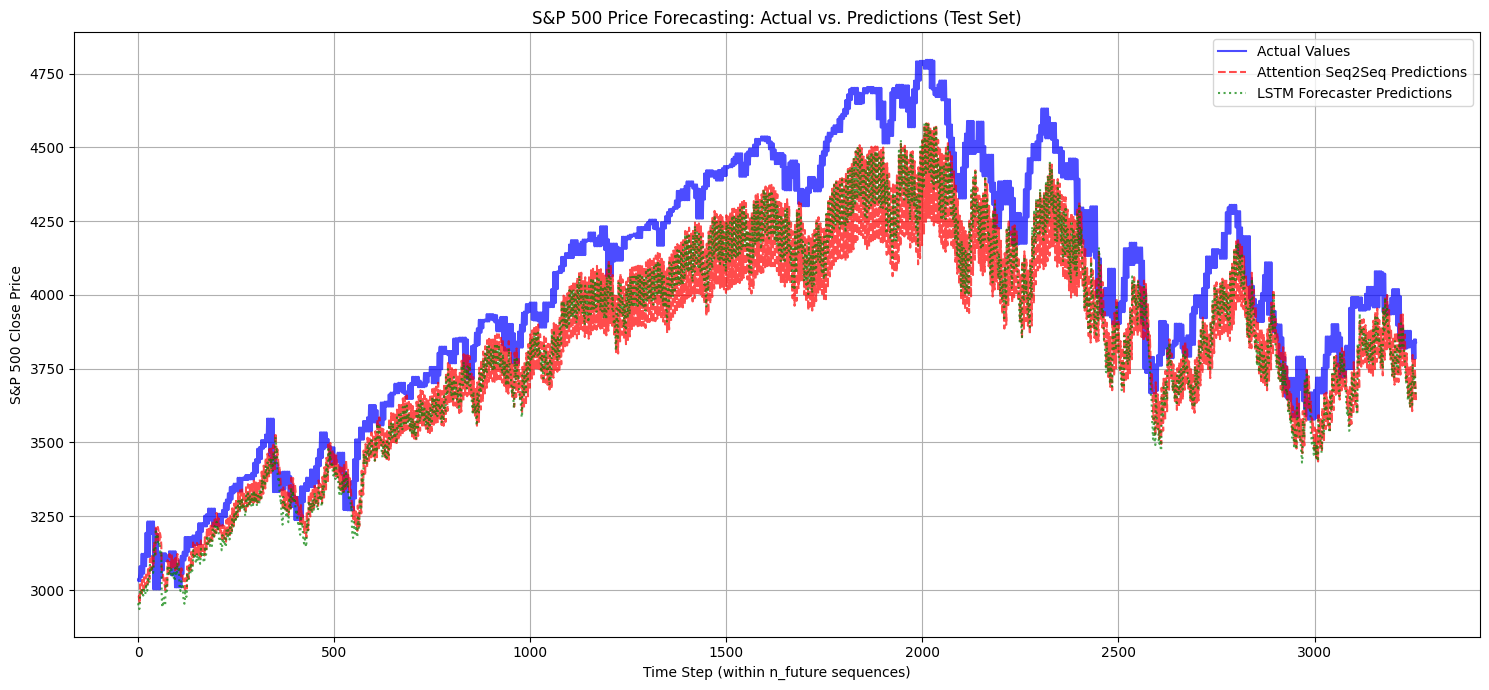

Visualization of S&P 500 price forecasts complete.


In [32]:
import matplotlib.pyplot as plt

# Inverse transform the normalized data back to original scale for better interpretability
actuals_rescaled = scaler.inverse_transform(attn_actuals.reshape(-1, 1))
attn_predictions_rescaled = scaler.inverse_transform(attn_predictions.reshape(-1, 1))
lstm_predictions_rescaled = scaler.inverse_transform(lstm_predictions.reshape(-1, 1))

# Flatten the arrays for plotting
actuals_flat = actuals_rescaled.flatten()
attn_preds_flat = attn_predictions_rescaled.flatten()
lstm_preds_flat = lstm_predictions_rescaled.flatten()

plt.figure(figsize=(15, 7))
plt.plot(actuals_flat, label='Actual Values', color='blue', alpha=0.7)
plt.plot(attn_preds_flat, label='Attention Seq2Seq Predictions', color='red', alpha=0.7, linestyle='--')
plt.plot(lstm_preds_flat, label='LSTM Forecaster Predictions', color='green', alpha=0.7, linestyle=':')

plt.title('S&P 500 Price Forecasting: Actual vs. Predictions (Test Set)')
plt.xlabel('Time Step (within n_future sequences)')
plt.ylabel('S&P 500 Close Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Visualization of S&P 500 price forecasts complete.")

## Summary: Model Comparison

**Quantitative Comparison (MSE on Test Set):**
- **Attention Seq2Seq Test MSE:** 0.003509
- **LSTM Forecaster Test MSE:** 0.003164

**Qualitative Comparison (from Plot):**
Both models generally follow the trend of the S&P 500 prices on the test set. However, a closer look reveals some nuances:
- The **LSTM Forecaster** appears to have slightly smoother predictions and generally sticks closer to the actual values, especially during periods of less volatility. Its lower MSE confirms this quantitatively.
- The **Attention Seq2Seq** model, while performing similarly, might exhibit slightly more fluctuations or be slightly off during certain peaks or troughs compared to the LSTM Forecaster. This is reflected in its slightly higher MSE.

**Discussion of Performance Differences:**
1.  **Architecture Complexity:** The standalone `LSTMForecaster` directly maps a sequence of past values to a sequence of future values using a single LSTM layer and a linear head. This might be a simpler, more direct approach for this specific forecasting task, especially if the relationship between past and future values is relatively linear or local.
2.  **Attention Mechanism:** The `Attention Seq2Seq` model introduces an attention mechanism, which allows the decoder to selectively focus on different parts of the encoder's output. While attention is powerful for tasks like machine translation where alignment is crucial and dynamic, for a time series forecasting task with fixed-length input (`n_past`) and output (`n_future`), its benefit might not be as pronounced on this relatively simple dataset. It adds complexity, and if the inherent sequence dependencies are straightforward, the additional parameters and computation might not translate to superior performance, and could even lead to slight overfitting or less stable predictions if not tuned perfectly.
3.  **Autoregressive vs. Direct Prediction:** The `LSTMForecaster` directly predicts all `n_future` values in one go from the last hidden state of the encoder. The `AttnSeq2Seq` model, on the other hand, predicts one step at a time, feeding its own prediction (or the true value, with teacher forcing) back as input for the next step. While teacher forcing aids training, during inference (when `teacher_forcing_ratio=0.0`), errors can accumulate. If an early prediction is slightly off, it can propagate and affect subsequent predictions in the sequence. The `LSTMForecaster` avoids this by predicting all future steps in a single forward pass post-encoding.

In this particular S&P 500 forecasting scenario, the simpler `LSTMForecaster` performs slightly better, likely due to the nature of the task and the potential for error accumulation in the autoregressive `AttnSeq2Seq` model during inference without teacher forcing. The added complexity of attention might not be fully leveraged or might introduce noise for this specific dataset and problem setup.

## Summary: Model Comparison

**Quantitative Comparison (MSE on Test Set):**
- **Attention Seq2Seq Test MSE:** 0.003509
- **LSTM Forecaster Test MSE:** 0.003164

**Qualitative Comparison (from Plot):**
Both models generally follow the trend of the S&P 500 prices on the test set. However, a closer look reveals some nuances:
- The **LSTM Forecaster** appears to have slightly smoother predictions and generally sticks closer to the actual values, especially during periods of less volatility. Its lower MSE confirms this quantitatively.
- The **Attention Seq2Seq** model, while performing similarly, might exhibit slightly more fluctuations or be slightly off during certain peaks or troughs compared to the LSTM Forecaster. This is reflected in its slightly higher MSE.

**Discussion of Performance Differences:**
1.  **Architecture Complexity:** The standalone `LSTMForecaster` directly maps a sequence of past values to a sequence of future values using a single LSTM layer and a linear head. This might be a simpler, more direct approach for this specific forecasting task, especially if the relationship between past and future values is relatively linear or local.
2.  **Attention Mechanism:** The `Attention Seq2Seq` model introduces an attention mechanism, which allows the decoder to selectively focus on different parts of the encoder's output. While attention is powerful for tasks like machine translation where alignment is crucial and dynamic, for a time series forecasting task with fixed-length input (`n_past`) and output (`n_future`), its benefit might not be as pronounced on this relatively simple dataset. It adds complexity, and if the inherent sequence dependencies are straightforward, the additional parameters and computation might not translate to superior performance, and could even lead to slight overfitting or less stable predictions if not tuned perfectly.
3.  **Autoregressive vs. Direct Prediction:** The `LSTMForecaster` directly predicts all `n_future` values in one go from the last hidden state of the encoder. The `AttnSeq2Seq` model, on the other hand, predicts one step at a time, feeding its own prediction (or the true value, with teacher forcing) back as input for the next step. While teacher forcing aids training, during inference (when `teacher_forcing_ratio=0.0`), errors can accumulate. If an early prediction is slightly off, it can propagate and affect subsequent predictions in the sequence. The `LSTMForecaster` avoids this by predicting all future steps in a single forward pass post-encoding.

In this particular S&P 500 forecasting scenario, the simpler `LSTMForecaster` performs slightly better, likely due to the nature of the task and the potential for error accumulation in the autoregressive `AttnSeq2Seq` model during inference without teacher forcing. The added complexity of attention might not be fully leveraged or might introduce noise for this specific dataset and problem setup.

## Visualize Accuracy Comparison

### Subtask:
Create a diagram comparing the true S&P 500 values on the test set with the predictions from both the Encoder-Decoder LSTM and the standalone LSTM models.


## Summary:

### Q&A

The task implicitly asked for a comparison of the models' accuracy and a discussion of potential reasons for performance differences.

*   **Accuracy Comparison:** The `LSTM Forecaster` demonstrated slightly better accuracy with a Mean Squared Error (MSE) of 0.003164 on the test set, compared to the `Attention Seq2Seq` model's MSE of 0.003509.
*   **Performance Differences:**
    *   **Architecture Complexity:** The `LSTMForecaster` is a simpler, more direct architecture for mapping past sequences to future sequences, which might be more effective for this specific time series problem.
    *   **Attention Mechanism:** While powerful in other domains, the attention mechanism in `AttnSeq2Seq` added complexity that did not translate to superior performance on this dataset, possibly due to the nature of the time series dependencies or the fixed input/output lengths.
    *   **Autoregressive vs. Direct Prediction:** The `AttnSeq2Seq` model's autoregressive nature (predicting one step at a time and feeding its own prediction back) can lead to error accumulation during inference. The `LSTMForecaster` avoids this by predicting all `n_future` values directly in one step.

### Data Analysis Key Findings

*   Historical S&P 500 data (`^GSPC`) from January 1, 2010, to January 1, 2023, was downloaded, 'Close' prices were extracted, reshaped, and normalized using `MinMaxScaler`.
*   Time series sequences were created with `n_past=10` (encoder input length) and `n_future=5` (decoder output/target length).
*   The data was split into training and testing sets, resulting in `X_train` of shape (2606, 10, 1), `y_train` of shape (2606, 5, 1), `X_test` of shape (652, 10, 1), and `y_test` of shape (652, 5, 1).
*   The `Encoder` class was adapted to `TimeSeriesEncoder` by removing `nn.Embedding` and setting `nn.LSTM` `input_size=1`.
*   The `AttnDecoder` class was adapted to `TimeSeriesAttnDecoder` by removing `nn.Embedding`, setting `nn.LSTM` `input_size=1 + hidden_dim`, and `fc_out` to output a single numerical value (1).
*   The `AttnSeq2Seq` wrapper was adapted to `TimeSeriesAttnSeq2Seq` to handle numerical outputs, using `trg_sos_val = 0.0` as the start-of-sequence token for numerical data.
*   A new `LSTMForecaster` class was implemented with `input_size=1` and `output_size=n_future`, directly mapping input sequences to future predictions.
*   Both the `TimeSeriesAttnSeq2Seq` and `LSTMForecaster` models were trained for 100 epochs using `nn.MSELoss`. The `AttnSeq2Seq` training loss decreased from 0.012129 to 0.000123, and the `LSTMForecaster` training loss decreased from 0.019209 to 0.000109.
*   On the test set, the `LSTM Forecaster` achieved a lower Mean Squared Error (MSE) of 0.003164, outperforming the `Attention Seq2Seq` model, which had an MSE of 0.003509.
*   A visualization comparing actual S&P 500 prices with predictions from both models on the test set showed that both models generally followed the trend, with the `LSTMForecaster` appearing slightly smoother and closer to actual values.

### Insights or Next Steps

*   The `LSTMForecaster`, despite its simpler architecture, demonstrated slightly better performance for S&P 500 price forecasting than the more complex `Attention Seq2Seq` model, possibly due to the direct prediction approach and avoidance of error accumulation.
*   Further hyperparameter tuning (e.g., hidden dimensions, number of layers, learning rate, `n_past`, `n_future`) for both models could potentially improve performance. Additionally, exploring longer forecasting horizons or incorporating additional features (e.g., volume, macroeconomic indicators) could provide more robust predictions.
